In [1]:
# ── IMPORTS ──────────────────────────────────────────────────────────
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#e6edf3',
    'text.color': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'grid.linewidth': 0.5,
    'font.family': 'monospace',
    'font.size': 9,
})

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
# ── BLACK-SCHOLES MODEL ───────────────────────────────────────────────
class BlackScholes:
    """
    Black-Scholes model for European options pricing.
    
    Parameters
    ----------
    S : float — Current spot price
    K : float — Strike price
    T : float — Time to expiry in years (e.g. 30 days = 30/365)
    r : float — Risk-free rate, annualized (e.g. 0.05 = 5%)
    sigma : float — Implied volatility, annualized (e.g. 0.20 = 20%)
    """

    def __init__(self, S: float, K: float, T: float, r: float, sigma: float):
        self.S     = S
        self.K     = K
        self.T     = T
        self.r     = r
        self.sigma = sigma
        self._d1, self._d2 = self._compute_d1_d2()

    def _compute_d1_d2(self):
        """Core of the Black-Scholes formula."""
        if self.T <= 0 or self.sigma <= 0:
            return 0.0, 0.0
        d1 = (np.log(self.S / self.K) + 
              (self.r + 0.5 * self.sigma**2) * self.T) / \
             (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)
        return d1, d2

    # ── PRICES ──────────────────────────────────────────────────────
    def call_price(self) -> float:
        """European call option price."""
        if self.T <= 0:
            return max(self.S - self.K, 0)
        return (self.S * norm.cdf(self._d1) - 
                self.K * np.exp(-self.r * self.T) * norm.cdf(self._d2))

    def put_price(self) -> float:
        """European put option price via put-call parity."""
        if self.T <= 0:
            return max(self.K - self.S, 0)
        return (self.K * np.exp(-self.r * self.T) * norm.cdf(-self._d2) - 
                self.S * norm.cdf(-self._d1))

    def price(self, option_type: str) -> float:
        """Price by option type: 'call' or 'put'."""
        return self.call_price() if option_type.lower() == 'call' else self.put_price()

    # ── GREEKS ──────────────────────────────────────────────────────
    def delta(self, option_type='call') -> float:
        """
        Delta — sensitivity to spot price.
        Call: [0, 1]  |  Put: [-1, 0]
        Trader use: number of shares to hold for delta-neutral hedge.
        """
        if option_type == 'call':
            return norm.cdf(self._d1)
        return norm.cdf(self._d1) - 1

    def gamma(self) -> float:
        """
        Gamma — rate of change of delta (same for calls and puts).
        Trader use: how quickly your hedge becomes stale.
        High gamma near expiry = rebalance frequently.
        """
        if self.T <= 0:
            return 0.0
        return norm.pdf(self._d1) / (self.S * self.sigma * np.sqrt(self.T))

    def vega(self) -> float:
        """
        Vega — sensitivity to 1% change in implied vol.
        Same for calls and puts.
        Trader use: P&L impact of vol moves. Divide by 100 for per 1bp.
        """
        if self.T <= 0:
            return 0.0
        return self.S * norm.pdf(self._d1) * np.sqrt(self.T) / 100

    def theta(self, option_type='call') -> float:
        """
        Theta — daily time decay (per calendar day).
        Always negative for long options.
        Trader use: how much you lose per day just by holding.
        """
        if self.T <= 0:
            return 0.0
        term1 = -(self.S * norm.pdf(self._d1) * self.sigma) / (2 * np.sqrt(self.T))
        term2 = self.r * self.K * np.exp(-self.r * self.T)
        if option_type == 'call':
            return (term1 - term2 * norm.cdf(self._d2)) / 365
        return (term1 + term2 * norm.cdf(-self._d2)) / 365

    def rho(self, option_type='call') -> float:
        """
        Rho — sensitivity to 1% change in interest rates.
        Trader use: mainly relevant for long-dated options.
        """
        if self.T <= 0:
            return 0.0
        factor = self.K * self.T * np.exp(-self.r * self.T) / 100
        if option_type == 'call':
            return factor * norm.cdf(self._d2)
        return -factor * norm.cdf(-self._d2)

    def all_greeks(self, option_type='call') -> dict:
        """Return all Greeks as a dictionary."""
        return {
            'delta': self.delta(option_type),
            'gamma': self.gamma(),
            'vega':  self.vega(),
            'theta': self.theta(option_type),
            'rho':   self.rho(option_type),
        }

    def summary(self, option_type='call') -> None:
        """Print a clean trading summary."""
        greeks = self.all_greeks(option_type)
        price  = self.price(option_type)
        print(f"\n{'═'*45}")
        print(f"  BLACK-SCHOLES · {option_type.upper()} OPTION PRICER")
        print(f"{'═'*45}")
        print(f"  Spot     : ${self.S:>10.2f}")
        print(f"  Strike   : ${self.K:>10.2f}")
        print(f"  Expiry   : {self.T*365:>8.0f} days  ({self.T:.4f}y)")
        print(f"  Vol      : {self.sigma*100:>9.1f}%")
        print(f"  Rate     : {self.r*100:>9.1f}%")
        print(f"{'─'*45}")
        print(f"  PRICE    : ${price:>10.4f}")
        print(f"{'─'*45}")
        print(f"  Delta    : {greeks['delta']:>10.4f}   (hedge ratio)")
        print(f"  Gamma    : {greeks['gamma']:>10.4f}   (delta change / $1)")
        print(f"  Vega     : {greeks['vega']:>10.4f}   (P&L / 1% vol move)")
        print(f"  Theta    : {greeks['theta']:>10.4f}   (P&L / day)")
        print(f"  Rho      : {greeks['rho']:>10.4f}   (P&L / 1% rate move)")
        print(f"{'═'*45}\n")

print("✓ BlackScholes class defined")

✓ BlackScholes class defined


In [3]:
# ── EXAMPLE : SPY ATM CALL · 30 DAYS ─────────────────────────────────
# Real-world parameters (Mar 2026)
# SPY spot ~$562, VIX ~28 → implied vol ~28%
# 10Y Treasury ~4.3%

bs = BlackScholes(
    S     = 562.00,   # SPY spot price
    K     = 562.00,   # ATM strike (= spot)
    T     = 30/365,   # 30 calendar days to expiry
    r     = 0.043,    # risk-free rate (10Y UST)
    sigma = 0.28,     # implied vol (VIX proxy)
)

bs.summary('call')
bs.summary('put')


═════════════════════════════════════════════
  BLACK-SCHOLES · CALL OPTION PRICER
═════════════════════════════════════════════
  Spot     : $    562.00
  Strike   : $    562.00
  Expiry   :       30 days  (0.0822y)
  Vol      :      28.0%
  Rate     :       4.3%
─────────────────────────────────────────────
  PRICE    : $   18.9700
─────────────────────────────────────────────
  Delta    :     0.5335   (hedge ratio)
  Gamma    :     0.0088   (delta change / $1)
  Vega     :     0.6405   (P&L / 1% vol move)
  Theta    :    -0.3320   (P&L / day)
  Rho      :     0.2309   (P&L / 1% rate move)
═════════════════════════════════════════════


═════════════════════════════════════════════
  BLACK-SCHOLES · PUT OPTION PRICER
═════════════════════════════════════════════
  Spot     : $    562.00
  Strike   : $    562.00
  Expiry   :       30 days  (0.0822y)
  Vol      :      28.0%
  Rate     :       4.3%
─────────────────────────────────────────────
  PRICE    : $   16.9872
─────────────────

In [4]:
# ── IMPLIED VOLATILITY SOLVER ─────────────────────────────────────────
def implied_vol(market_price: float, S: float, K: float, T: float,
                r: float, option_type: str = 'call',
                tol: float = 1e-6, max_iter: int = 100) -> float:
    """
    Solve for implied volatility using Brent's method.
    
    More robust than Newton-Raphson — handles flat vega regions
    near expiry where Newton-Raphson can diverge.
    
    Parameters
    ----------
    market_price : float — observed option price in the market
    tol          : float — convergence tolerance
    max_iter     : int   — maximum iterations
    
    Returns
    -------
    float — implied volatility (annualized), or np.nan if no solution
    """
    # Intrinsic value check — market price must exceed intrinsic value
    intrinsic = max(S - K, 0) if option_type == 'call' else max(K - S, 0)
    if market_price <= intrinsic:
        return np.nan
    if market_price <= 0 or T <= 0:
        return np.nan

    # Objective function: BS price - market price = 0
    def objective(sigma):
        bs = BlackScholes(S, K, T, r, sigma)
        return bs.price(option_type) - market_price

    try:
        # Brent's method: bracket between 0.1% and 500% vol
        iv = brentq(objective, a=0.001, b=5.0, xtol=tol, maxiter=max_iter)
        return iv
    except ValueError:
        return np.nan


# ── TEST : recover sigma from our own price ───────────────────────────
# We know the answer should be exactly 0.28 (28%)
market_call_price = bs.call_price()   # $18.97 from previous cell
market_put_price  = bs.put_price()    # $16.99

iv_call = implied_vol(market_call_price, S=562, K=562, T=30/365, r=0.043, option_type='call')
iv_put  = implied_vol(market_put_price,  S=562, K=562, T=30/365, r=0.043, option_type='put')

print(f"Input vol          : 28.00%")
print(f"IV recovered (call): {iv_call*100:.4f}%")
print(f"IV recovered (put) : {iv_put*100:.4f}%")
print(f"\n✓ Solver working correctly" if abs(iv_call - 0.28) < 1e-4 else "✗ Check solver")

# ── REAL WORLD TEST : market price → IV ───────────────────────────────
# Suppose the market is quoting SPY 562 call at $20.50
# (higher than our theoretical $18.97 → market implies higher vol)
market_quote = 20.50
iv_market = implied_vol(market_quote, S=562, K=562, T=30/365, r=0.043, option_type='call')

print(f"\nMarket quote       : ${market_quote}")
print(f"Our theoretical    : ${market_call_price:.2f}")
print(f"Implied vol        : {iv_market*100:.2f}%")
print(f"Our model vol      : 28.00%")
print(f"Vol difference     : {(iv_market - 0.28)*100:+.2f}% → market pricing MORE uncertainty than our model")

Input vol          : 28.00%
IV recovered (call): 28.0000%
IV recovered (put) : 28.0000%

✓ Solver working correctly

Market quote       : $20.5
Our theoretical    : $18.97
Implied vol        : 30.39%
Our model vol      : 28.00%
Vol difference     : +2.39% → market pricing MORE uncertainty than our model


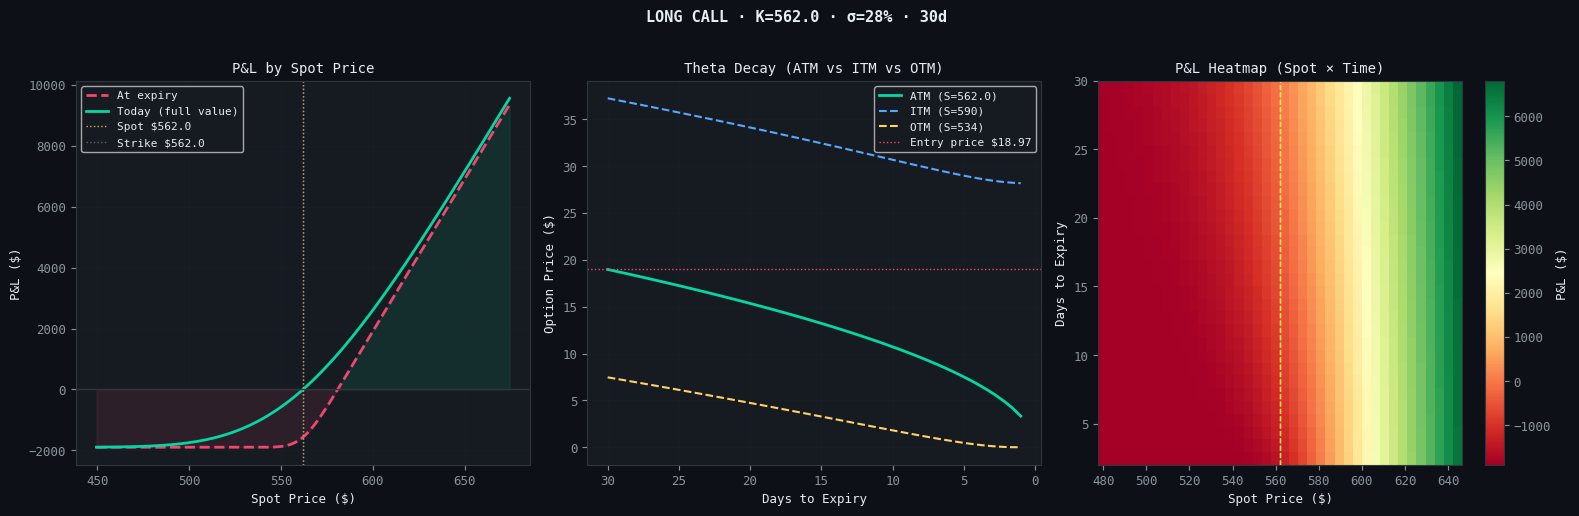


✓ Saved → pnl_simulation.png
  Entry premium paid : $1897.00 (1 contract)
  Max loss (long)    : $1897.00
  Breakeven at expiry: $580.97


In [5]:
# ── P&L SIMULATION ────────────────────────────────────────────────────
def pnl_simulation(S0: float, K: float, T: float, r: float, sigma: float,
                   option_type: str = 'call', position: str = 'long',
                   contracts: int = 1) -> None:
    """
    Simulate P&L across spot prices and time to expiry.
    
    Produces 3 charts:
    1. Payoff diagram at expiry vs today
    2. Theta decay curve over time
    3. P&L heatmap (spot × time)
    """
    multiplier = 100  # 1 contract = 100 shares
    sign = 1 if position == 'long' else -1

    # Entry price
    entry = BlackScholes(S0, K, T, r, sigma).price(option_type)
    total_premium = entry * multiplier * contracts * sign

    # ── GRID SETUP ────────────────────────────────────────────────
    spot_range  = np.linspace(S0 * 0.80, S0 * 1.20, 200)   # ±20% spot
    time_range  = np.linspace(T, 1/365, 50)                  # T → 1 day left
    days_range  = time_range * 365

    # ── CHART 1 : PAYOFF DIAGRAM ──────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'{position.upper()} {option_type.upper()} · K={K} · σ={sigma*100:.0f}% · {T*365:.0f}d',
                 fontsize=11, fontweight='bold', color='#e6edf3', y=1.02)

    ax1 = axes[0]
    # P&L at expiry (intrinsic only)
    pnl_expiry = []
    for S in spot_range:
        bs_exp = BlackScholes(S, K, 1/365, r, sigma)
        pnl = (bs_exp.price(option_type) - entry) * multiplier * contracts * sign
        pnl_expiry.append(pnl)

    # P&L today (full option value)
    pnl_today = []
    for S in spot_range:
        bs_now = BlackScholes(S, K, T, r, sigma)
        pnl = (bs_now.price(option_type) - entry) * multiplier * contracts * sign
        pnl_today.append(pnl)

    ax1.plot(spot_range, pnl_expiry, color='#ef476f', linewidth=2,
             label='At expiry', linestyle='--')
    ax1.plot(spot_range, pnl_today, color='#06d6a0', linewidth=2,
             label='Today (full value)')
    ax1.axhline(0, color='#30363d', linewidth=1)
    ax1.axvline(S0, color='#ffd166', linewidth=1, linestyle=':', alpha=0.8, label=f'Spot ${S0}')
    ax1.axvline(K,  color='#8b949e', linewidth=1, linestyle=':', alpha=0.6, label=f'Strike ${K}')
    ax1.fill_between(spot_range, pnl_expiry, 0,
                     where=[p > 0 for p in pnl_expiry],
                     alpha=0.1, color='#06d6a0')
    ax1.fill_between(spot_range, pnl_expiry, 0,
                     where=[p < 0 for p in pnl_expiry],
                     alpha=0.1, color='#ef476f')
    ax1.set_title('P&L by Spot Price', color='#e6edf3', fontsize=10)
    ax1.set_xlabel('Spot Price ($)')
    ax1.set_ylabel('P&L ($)')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # ── CHART 2 : THETA DECAY ─────────────────────────────────────
    ax2 = axes[1]
    decay_atm, decay_itm, decay_otm = [], [], []

    for t in time_range:
        decay_atm.append(BlackScholes(S0,        K,        t, r, sigma).price(option_type))
        decay_itm.append(BlackScholes(S0*1.05,   K,        t, r, sigma).price(option_type))
        decay_otm.append(BlackScholes(S0*0.95,   K,        t, r, sigma).price(option_type))

    ax2.plot(days_range, decay_atm, color='#06d6a0', linewidth=2, label=f'ATM (S={S0})')
    ax2.plot(days_range, decay_itm, color='#58a6ff', linewidth=1.5, linestyle='--',
             label=f'ITM (S={S0*1.05:.0f})')
    ax2.plot(days_range, decay_otm, color='#ffd166', linewidth=1.5, linestyle='--',
             label=f'OTM (S={S0*0.95:.0f})')
    ax2.axhline(entry, color='#ef476f', linewidth=1, linestyle=':',
                label=f'Entry price ${entry:.2f}')
    ax2.invert_xaxis()
    ax2.set_title('Theta Decay (ATM vs ITM vs OTM)', color='#e6edf3', fontsize=10)
    ax2.set_xlabel('Days to Expiry')
    ax2.set_ylabel('Option Price ($)')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # ── CHART 3 : P&L HEATMAP ─────────────────────────────────────
    ax3 = axes[2]
    spot_grid  = np.linspace(S0 * 0.85, S0 * 1.15, 40)
    time_grid  = np.linspace(T, 2/365, 30)
    pnl_matrix = np.zeros((len(time_grid), len(spot_grid)))

    for i, t in enumerate(time_grid):
        for j, S in enumerate(spot_grid):
            val = BlackScholes(S, K, t, r, sigma).price(option_type)
            pnl_matrix[i, j] = (val - entry) * multiplier * contracts * sign

    im = ax3.imshow(pnl_matrix, aspect='auto', cmap='RdYlGn',
                    extent=[spot_grid[0], spot_grid[-1],
                            time_grid[-1]*365, time_grid[0]*365],
                    origin='upper')
    plt.colorbar(im, ax=ax3, label='P&L ($)')
    ax3.axvline(S0, color='white', linewidth=1, linestyle='--', alpha=0.7)
    ax3.axvline(K,  color='yellow', linewidth=1, linestyle='--', alpha=0.7)
    ax3.set_title('P&L Heatmap (Spot × Time)', color='#e6edf3', fontsize=10)
    ax3.set_xlabel('Spot Price ($)')
    ax3.set_ylabel('Days to Expiry')

    plt.tight_layout()
    plt.savefig('pnl_simulation.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print(f"\n✓ Saved → pnl_simulation.png")
    print(f"  Entry premium paid : ${abs(total_premium):.2f} ({contracts} contract{'s' if contracts>1 else ''})")
    print(f"  Max loss (long)    : ${abs(total_premium):.2f}")
    print(f"  Breakeven at expiry: ${K + entry:.2f}" if option_type == 'call'
          else f"  Breakeven at expiry: ${K - entry:.2f}")


# ── RUN IT ────────────────────────────────────────────────────────────
pnl_simulation(
    S0          = 562.00,
    K           = 562.00,
    T           = 30/365,
    r           = 0.043,
    sigma       = 0.28,
    option_type = 'call',
    position    = 'long',
    contracts   = 1
)

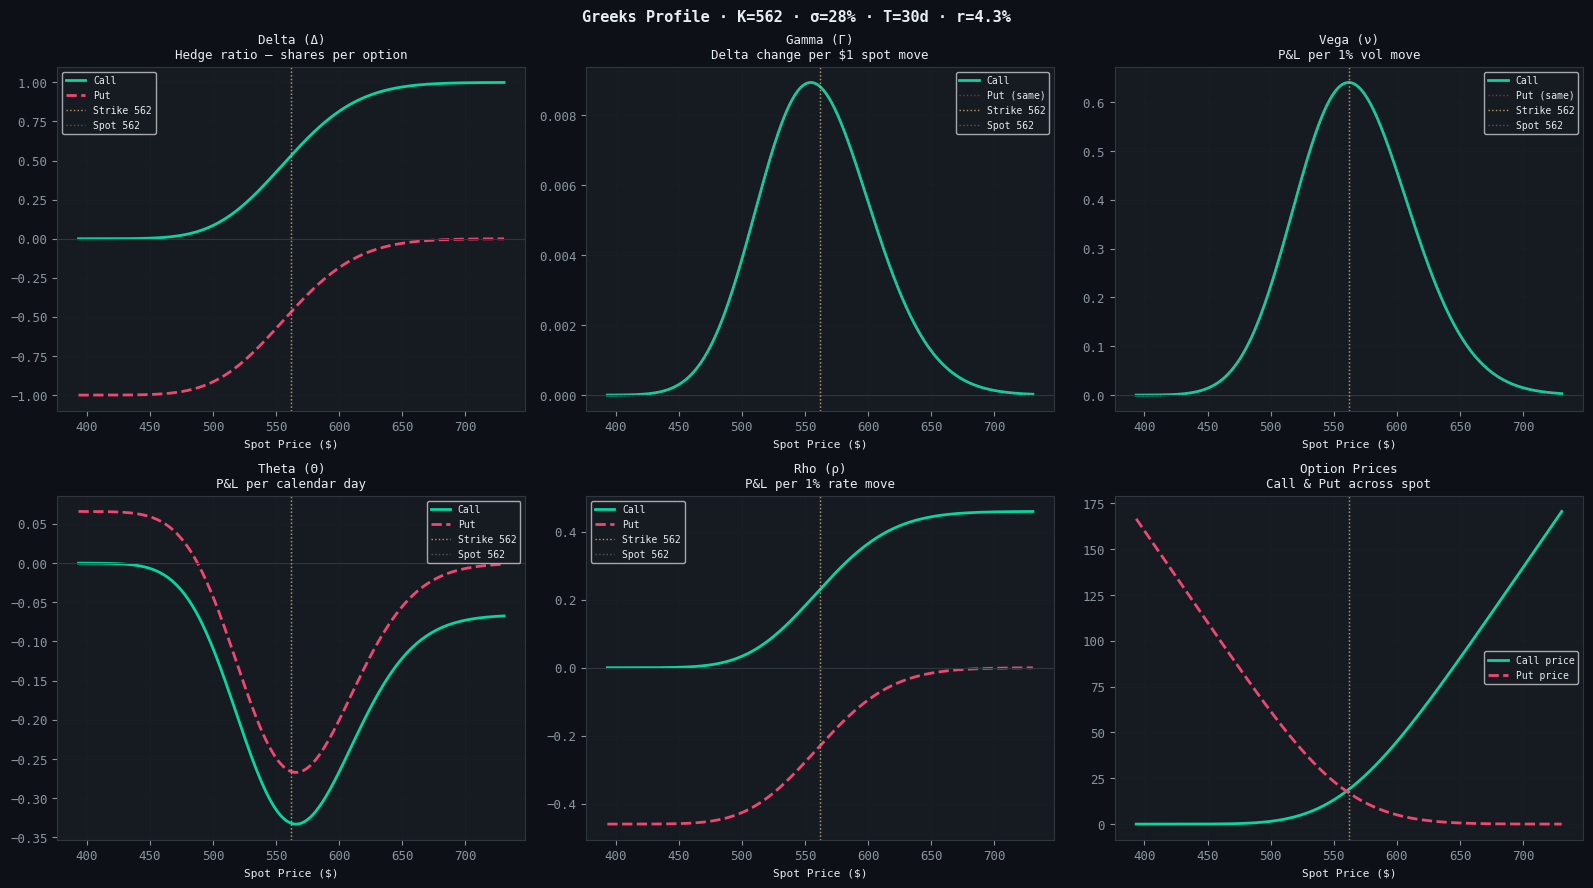

✓ Saved → greeks_profile.png


In [6]:
# ── GREEKS VISUALIZATION ──────────────────────────────────────────────
def plot_greeks(S0: float, K: float, T: float, r: float, sigma: float) -> None:
    """
    Plot all 5 Greeks across a range of spot prices.
    Shows both call and put where relevant.
    """
    spot_range = np.linspace(S0 * 0.70, S0 * 1.30, 300)

    # Compute Greeks across spot range
    greeks = {g: {'call': [], 'put': []} for g in ['delta', 'gamma', 'vega', 'theta', 'rho']}

    for S in spot_range:
        bs = BlackScholes(S, K, T, r, sigma)
        for opt in ['call', 'put']:
            g = bs.all_greeks(opt)
            for greek in greeks:
                greeks[greek][opt].append(g[greek])

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f'Greeks Profile · K={K} · σ={sigma*100:.0f}% · T={T*365:.0f}d · r={r*100:.1f}%',
                 fontsize=11, fontweight='bold', color='#e6edf3')
    axes = axes.flatten()

    configs = [
        ('delta', 'Delta (Δ)', 'Hedge ratio — shares per option'),
        ('gamma', 'Gamma (Γ)', 'Delta change per $1 spot move'),
        ('vega',  'Vega (ν)',  'P&L per 1% vol move'),
        ('theta', 'Theta (Θ)', 'P&L per calendar day'),
        ('rho',   'Rho (ρ)',   'P&L per 1% rate move'),
    ]

    for idx, (greek, title, subtitle) in enumerate(configs):
        ax = axes[idx]
        ax.plot(spot_range, greeks[greek]['call'],
                color='#06d6a0', linewidth=2, label='Call')
        if greek not in ['gamma', 'vega']:
            ax.plot(spot_range, greeks[greek]['put'],
                    color='#ef476f', linewidth=2, label='Put', linestyle='--')
        else:
            # Gamma and vega are identical for calls and puts
            ax.plot(spot_range, greeks[greek]['put'],
                    color='#ef476f', linewidth=1, linestyle=':', alpha=0.5, label='Put (same)')

        ax.axhline(0,  color='#30363d', linewidth=0.8)
        ax.axvline(K,  color='#ffd166', linewidth=1,
                   linestyle=':', alpha=0.7, label=f'Strike {K}')
        ax.axvline(S0, color='#8b949e', linewidth=1,
                   linestyle=':', alpha=0.5, label=f'Spot {S0}')
        ax.set_title(f'{title}\n{subtitle}', color='#e6edf3', fontsize=9)
        ax.set_xlabel('Spot Price ($)', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    # 6th panel — option prices for context
    ax = axes[5]
    call_prices = [BlackScholes(S, K, T, r, sigma).call_price() for S in spot_range]
    put_prices  = [BlackScholes(S, K, T, r, sigma).put_price()  for S in spot_range]
    ax.plot(spot_range, call_prices, color='#06d6a0', linewidth=2, label='Call price')
    ax.plot(spot_range, put_prices,  color='#ef476f', linewidth=2,
            linestyle='--', label='Put price')
    ax.axvline(K,  color='#ffd166', linewidth=1, linestyle=':', alpha=0.7)
    ax.axvline(S0, color='#8b949e', linewidth=1, linestyle=':', alpha=0.5)
    ax.set_title('Option Prices\nCall & Put across spot', color='#e6edf3', fontsize=9)
    ax.set_xlabel('Spot Price ($)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('greeks_profile.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print("✓ Saved → greeks_profile.png")


# ── RUN ───────────────────────────────────────────────────────────────
plot_greeks(S0=562, K=562, T=30/365, r=0.043, sigma=0.28)